In [1]:
import pandas as pd 

In [2]:
import numpy as np

In [3]:
# First we are load then data 
df = pd.read_csv('./housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [5]:
# Create a rondom data set 
def shuffle_and_split(data,test_ratio):
    np.random.seed(42)
    shuffle_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffle_indices[:test_set_size]
    train_indeces = shuffle_indices[test_set_size:]
    return data.iloc[train_indeces],data.iloc[test_indices]

In [6]:
train , test = shuffle_and_split(df,0.4)

In [7]:
# From Skleran se data selections 
from sklearn.model_selection import train_test_split
train , test = train_test_split(df,test_size=0.2,random_state=42)

In [8]:
print(train.head())
print(test.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                  33         3126           627.0   
8267     -118.16     33.77                  49         3382           787.0   
17445    -120.48     34.66                   4         1897           331.0   
14265    -117.11     32.69                  36         1421           367.0   
2271     -119.80     36.78                  43         2382           431.0   

       population  households  median_income  median_house_value  \
14196        2300         623         3.2596              103000   
8267         1314         756         3.8125              382100   
17445         915         336         4.1563              172600   
14265        1418         355         1.9425               93400   
2271          874         380         3.5542               96500   

      ocean_proximity  
14196      NEAR OCEAN  
8267       NEAR OCEAN  
17445      NEAR OCEAN  
14265      NEAR OCEA

In [9]:
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25,1505,NaN,1392,359,1.6812,47700,INLAND
3024,-119.46,35.14,30,2943,NaN,1565,584,2.5313,45800,INLAND
15663,-122.44,37.80,52,3830,NaN,1310,963,3.4801,500001,NEAR BAY
20484,-118.72,34.28,17,3051,NaN,1705,495,5.7376,218600,<1H OCEAN
9814,-121.93,36.62,34,2351,NaN,1063,428,3.7250,278000,NEAR OCEAN


In [10]:
# test.to_csv("test_data.csv",index=False)

In [11]:
# train.to_csv("Train_data.csv",index=False)

# Stratified shuffle split

In [12]:
df = pd.read_csv('./housing.csv')

In [13]:
# Median income ke aadhar par ek naya column banayege kyuki vah column(feature) bahut important hai 
df['income_category'] = pd.cut(df['median_income'] , bins=[0,1.5,3.0,4.5,6.0 , np.inf] , labels=[1,2,3,4,5])

In [14]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_category
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,2
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,2
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,2
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,2


Text(0, 0.5, 'Number of Instances')

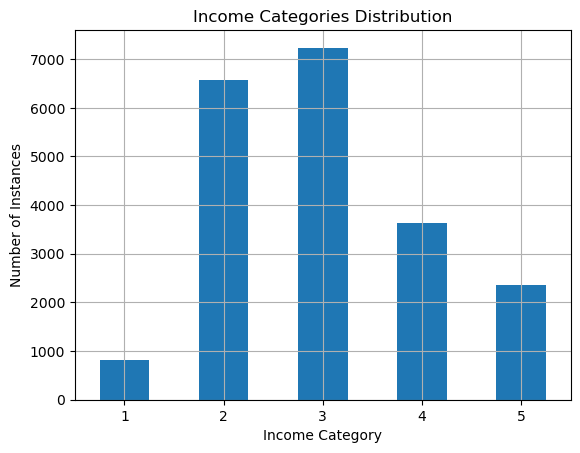

In [15]:
# Visualize the data
import matplotlib.pyplot as plt
df['income_category'].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

In [16]:
from sklearn.model_selection import train_test_split
train , test = train_test_split(df,test_size=0.2,random_state=42)
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_category
14196,-117.03,32.71,33,3126,627.0,2300,623,3.2596,103000,NEAR OCEAN,3
8267,-118.16,33.77,49,3382,787.0,1314,756,3.8125,382100,NEAR OCEAN,3
17445,-120.48,34.66,4,1897,331.0,915,336,4.1563,172600,NEAR OCEAN,3
14265,-117.11,32.69,36,1421,367.0,1418,355,1.9425,93400,NEAR OCEAN,2
2271,-119.80,36.78,43,2382,431.0,874,380,3.5542,96500,INLAND,3


In [17]:
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_category
20046,-119.01,36.06,25,1505,NaN,1392,359,1.6812,47700,INLAND,2
3024,-119.46,35.14,30,2943,NaN,1565,584,2.5313,45800,INLAND,2
15663,-122.44,37.80,52,3830,NaN,1310,963,3.4801,500001,NEAR BAY,3
20484,-118.72,34.28,17,3051,NaN,1705,495,5.7376,218600,<1H OCEAN,4
9814,-121.93,36.62,34,2351,NaN,1063,428,3.7250,278000,NEAR OCEAN,3


Text(0, 0.5, 'Number of Instances')

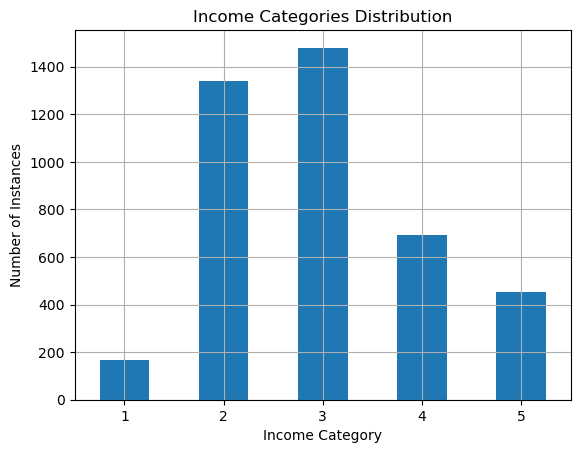

In [18]:
# visualze this test and train data 
test['income_category'].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

Text(0, 0.5, 'Number of Instances')

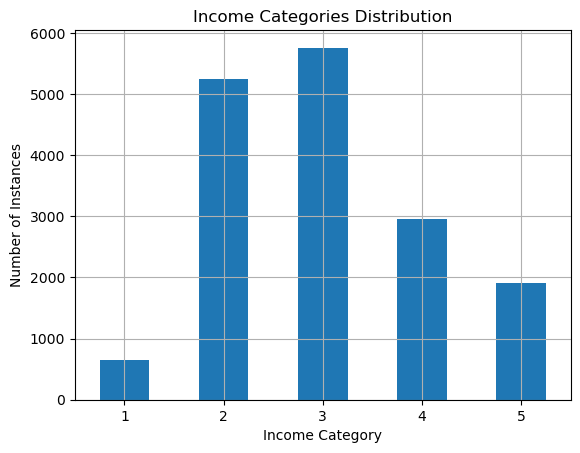

In [19]:
train['income_category'].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")

# sklearn se kisi column ka data dono jagah chahiye test data me bhi aur training data me bhi 

In [23]:
from sklearn.model_selection import StratifiedShuffleSplit

train, test = train_test_split(df,test_size=0.2,random_state=42,stratify=df["income_category"])

In [24]:
train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_category
12655,-121.46,38.52,29,3873,797.0,2237,706,2.1736,72100,INLAND,2
15502,-117.23,33.09,7,5320,855.0,2015,768,6.3373,279600,NEAR OCEAN,5
2908,-119.04,35.37,44,1618,310.0,667,300,2.8750,82700,INLAND,2
14053,-117.13,32.75,24,1877,519.0,898,483,2.2264,112500,NEAR OCEAN,2
20496,-118.70,34.28,27,3536,646.0,1837,580,4.4964,238300,<1H OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14,6665,1231.0,2026,1001,5.0900,268500,<1H OCEAN,4
12661,-121.42,38.51,15,7901,1422.0,4769,1418,2.8139,90400,INLAND,2
19263,-122.72,38.44,48,707,166.0,458,172,3.1797,140400,<1H OCEAN,3
19140,-122.70,38.31,14,3155,580.0,1208,501,4.1964,258100,<1H OCEAN,3


In [25]:
test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_category
5241,-118.39,34.12,29,6447,1012.0,2184,960,8.2816,500001,<1H OCEAN,5
17352,-120.42,34.89,24,2020,307.0,855,283,5.0099,162500,<1H OCEAN,4
3505,-118.45,34.25,36,1453,270.0,808,275,4.3839,204600,<1H OCEAN,3
7777,-118.10,33.91,35,1653,325.0,1072,301,3.2708,159700,<1H OCEAN,3
14155,-117.07,32.77,38,3779,614.0,1495,614,4.3529,184000,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19,2248,427.0,1207,368,2.8170,110000,<1H OCEAN,2
7275,-118.24,33.99,33,885,294.0,1270,282,2.1615,118800,<1H OCEAN,2
17223,-119.72,34.44,43,1781,342.0,663,358,4.7000,293800,<1H OCEAN,4
10786,-117.91,33.63,30,2071,412.0,1081,412,4.9125,335700,<1H OCEAN,4
